# Milestone 2 — photo check of the 40 biggest gains

The gain list is the one from `m2_masked.ipynb` section 7: end-minus-start on the masked table,
25% minimum land, gains ranked on their own. Section 7 found the gain list rural, lake-side and
seasonal, and said it needed the same photo check as the losses before any gain is quoted. M7 needs
one verified counter-example where green was gained. `m2_top_photo_check.ipynb` saw two of these
hexes on 2026-09-23 (Hennagara and Hesaraghatta north); this notebook looks at all 40.

1. **Water the mask missed**: the share of each hex's remaining land that read as open water each
   year. The same test as the loss check.
2. **The photos**: eight dry seasons of each hex, true colour, the hex in yellow, masked OSM water
   in red, kept wetland in magenta. The number under each year is the hex's normalised greenness.
3. **A verdict for every one of the 40**, written to `results/m2_gain_verdicts.csv`.

Each verdict answers one question: did green cover on dry land really come back or grow? The
categories:

- **real gain**: trees planted or growing in, visible in the photos (plantation, canopy, gardens);
- **lake margin**: a lake bed or shore greening as the lake refilled or went under weed, often past
  its mapped outline. Water behaviour, not land change;
- **regrowth**: grass or scrub coming back on cleared ground (an empty layout, earthworks), not trees;
- **crop swing**: farmland or grassland greener in 2026 with nothing new planted (gotcha 3);
- **doubtful**: the photos don't show a clear cause, or the rise is mostly a low 2019;
- **artefact**: the number comes from something other than land change.

**Needs Earth Engine.** Run with `EE_PROJECT` set.

In [1]:
import io
import json
import os
import socket
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box as shapely_box

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
METRIC = "EPSG:32643"
RGB_MAX = 3000
HEX_EDGE, MASK_EDGE, WETLAND_EDGE = "#ffe600", "#ff2d2d", "#ff4dff"
LAND_CUTOFF = 0.25
CLEAN_CUTOFF = 0.90
TOP = 40

old = pd.read_csv("results/m2_hex_table.csv")
table = pd.read_csv("results/m2_hex_table_masked.csv")
green = table.pivot(index="h3", columns="year", values="green")
YEARS = list(green.columns)
norm = green.sub(green.mean(axis=0), axis=1)
change = norm[YEARS[-1]] - norm[YEARS[0]]
land = table.groupby("h3").n_pixels.median() / old.groupby("h3").n_pixels.median()
gains = change[land.reindex(change.index) >= LAND_CUTOFF].nlargest(TOP).index
rank = pd.Series(range(1, TOP + 1), index=gains)

osm = gpd.read_file("data/osm_water.geojson")
masked = osm[osm["class"] != "wetland"]
wetland = osm[osm["class"] == "wetland"]
grid = gpd.read_file("data/hex_grid.geojson").to_crs(METRIC).set_index("h3")
pieces = gpd.overlay(grid.loc[gains].reset_index()[["h3", "geometry"]], osm.to_crs(METRIC)[["geometry"]])
clean_land = 1 - (pieces.dissolve(by="h3").area / grid.loc[gains].area).reindex(gains).fillna(0)

cache = json.loads(Path("data/place_names.json").read_text())


def locality(hx):
    lat, lng = h3.cell_to_latlng(hx)
    addr = cache[f"reverse?format=json&lat={lat:.5f}&lon={lng:.5f}&zoom=14"].get("address", {})
    return next((addr[k] for k in ("suburb", "neighbourhood", "village", "town", "city_district", "hamlet")
                 if k in addr), "")



socket.setdefaulttimeout(120)
ee.Initialize(project=os.environ["EE_PROJECT"])
ee.data.setDeadline(120_000)


def retry(fetch, tries=4):
    for attempt in range(tries):
        try:
            return fetch()
        except Exception as exc:
            if attempt == tries - 1:
                raise
            print(f"  retrying after {type(exc).__name__}")


def hex_geom(hx):
    return ee.Geometry.Polygon([[[lng, lat] for lat, lng in h3.cell_to_boundary(hx)]])


def composite(year, region):
    return (ee.ImageCollection(COLLECTION).filterBounds(region)
            .filterDate(f"{year}-02-01", f"{year}-03-31").median())


def to_fc(frame):
    return ee.FeatureCollection([ee.Feature(ee.Geometry(g.__geo_interface__)) for g in frame.geometry])


def near(frame, bounds):
    return frame[frame.intersects(shapely_box(*bounds))]


def land_mask(bounds):
    lakes = near(masked, bounds)
    return ee.Image.constant(1).paint(to_fc(lakes), 0) if len(lakes) else ee.Image.constant(1)


def outline(frame, colour, width=1):
    if frame.empty:
        return None
    return ee.Image().byte().paint(to_fc(frame), 1, width).selfMask().visualize(palette=[colour])


def thumb(image, region, px=230):
    def fetch():
        url = image.getThumbURL({"region": region, "dimensions": px, "format": "jpg"})
        return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format="jpg")
    return retry(fetch)


print(f"{TOP} biggest gains, all checked here; Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


40 biggest gains, all checked here; Earth Engine ready


---
## 1 — Water the mask missed

Of the pixels the mask kept as land, the share that read as open water (wetness index above zero),
per year. A hex at 0-1% every year is measured on dry land. One that jumps in some years has lake
inside its "land", and that alone moves its greenness.

In [2]:
leak = {}
for hx in gains:
    lat, lng = h3.cell_to_latlng(hx)
    mask = land_mask((lng - 0.01, lat - 0.01, lng + 0.01, lat + 0.01))
    geom = hex_geom(hx)
    shares = ee.List([composite(y, geom).normalizedDifference(["B3", "B11"]).gt(0).updateMask(mask)
                      .reduceRegion(ee.Reducer.mean(), geom, 10).values().get(0) for y in YEARS])
    leak[hx] = retry(shares.getInfo)

leak = pd.DataFrame(leak, index=YEARS).T
view = leak.map(lambda v: "" if v is None else f"{v:.0%}")
view.insert(0, "rank", rank[gains])
view.insert(1, "change", change[gains].round(3))
view.insert(2, "clean land", clean_land[gains].map("{:.0%}".format))
print("share of each hex's remaining land that read as open water, by year")
print(view.to_string())
print(f"\nhexes whose land read >5% water in any year: {(leak.max(axis=1) > 0.05).sum()} of {len(gains)}")

share of each hex's remaining land that read as open water, by year
                 rank  change clean land 2019 2020 2021 2022 2023 2024 2025 2026
8861893493fffff     1   0.312        11%  42%  33%  33%  30%   9%  11%  18%  12%
88601694a5fffff     2   0.198        32%   0%   0%   0%   0%   0%   0%   0%   0%
886016945dfffff     3   0.164       100%   0%   0%   0%   0%   0%   0%   0%   0%
88601696e5fffff     4   0.156       100%   0%   0%   0%   0%   0%   0%   0%   0%
88601692b5fffff     5   0.149        90%   0%   0%   0%   0%   0%   0%   0%   0%
8861892819fffff     6   0.146        60%   0%   0%   0%   3%  10%   4%   2%   2%
88601692adfffff     7   0.132        79%   0%   0%   0%   0%   1%   0%   0%   0%
8861892297fffff     8   0.124        93%   0%   0%   0%   0%   0%   0%   0%   0%
8861892d07fffff     9   0.123       100%   0%   0%   0%   0%   0%   0%   0%   0%
88601692b7fffff    10   0.122        61%   0%   0%   0%   1%   2%   2%   0%   1%
886016962dfffff    11   0.121        74% 

---
## 2 — The photos

All 40, one row each. Yellow is the hex, red is masked OSM water, magenta is kept wetland. The
number under each year is the normalised greenness the ranking uses; the change is the last minus
the first.

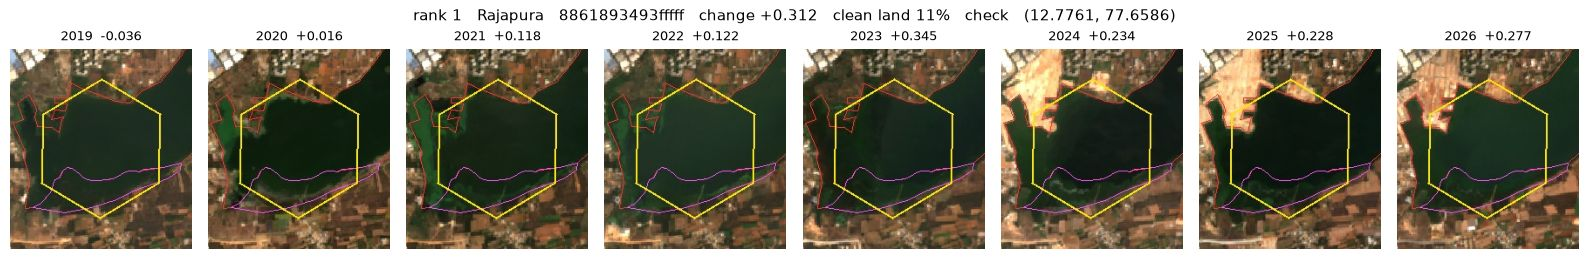

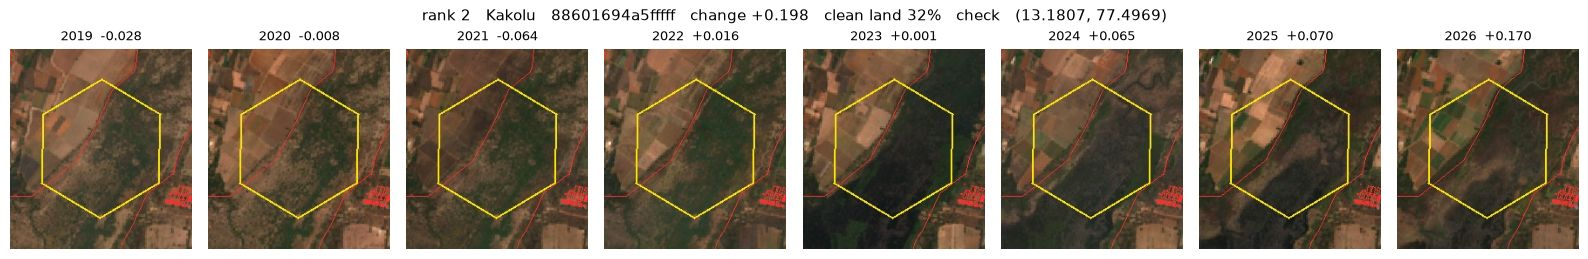

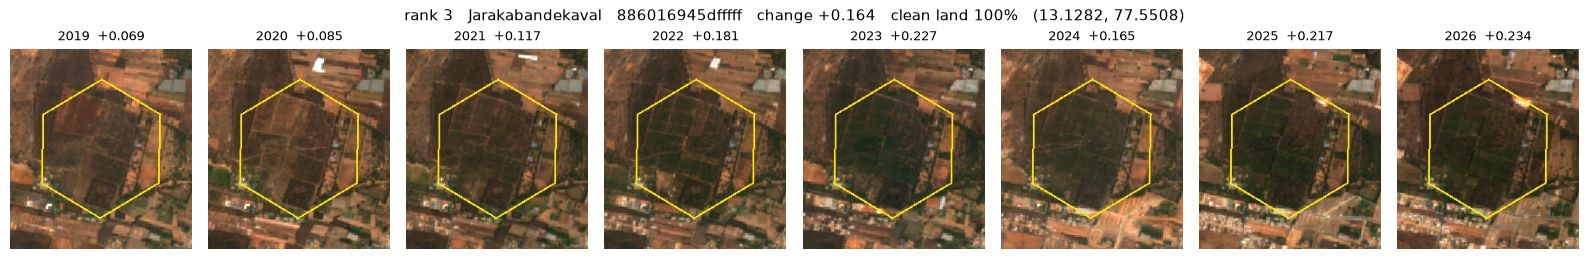

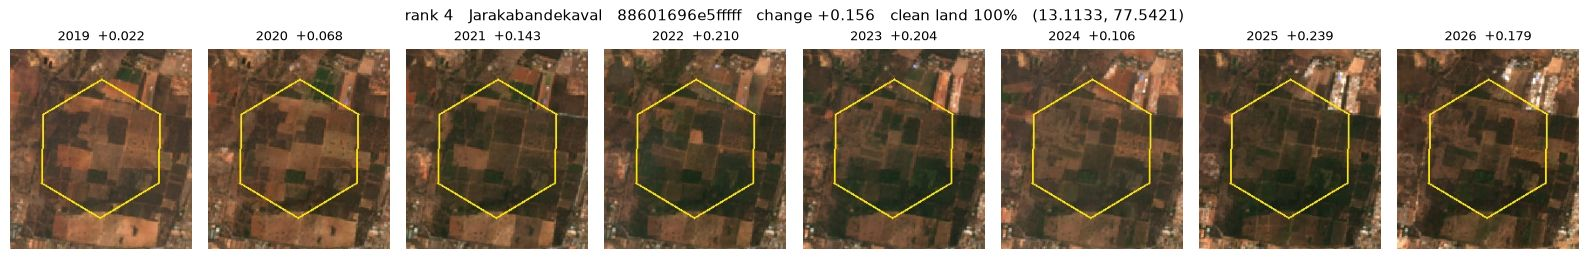

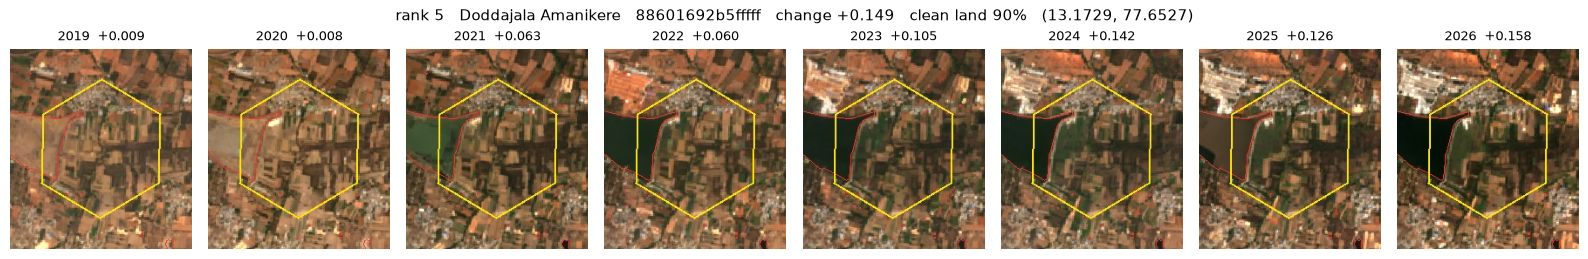

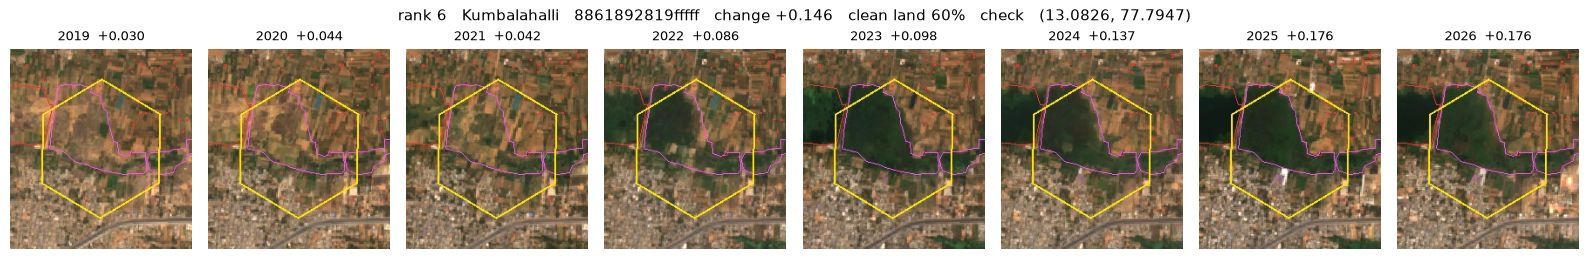

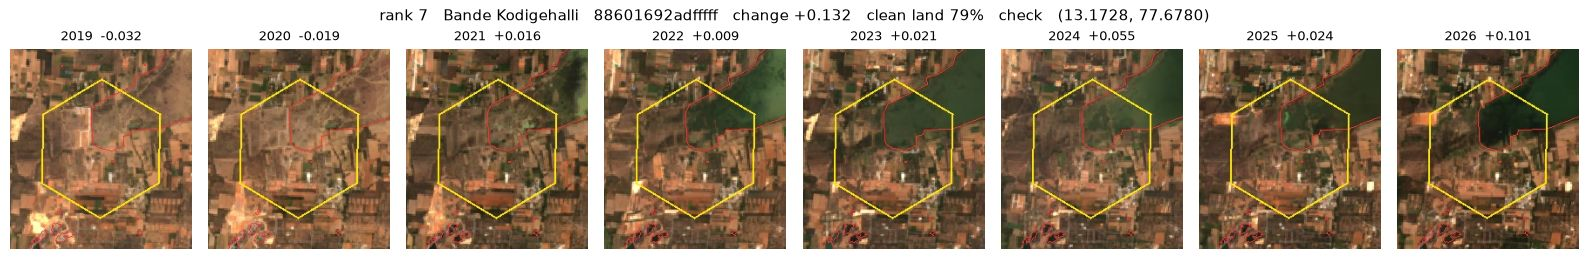

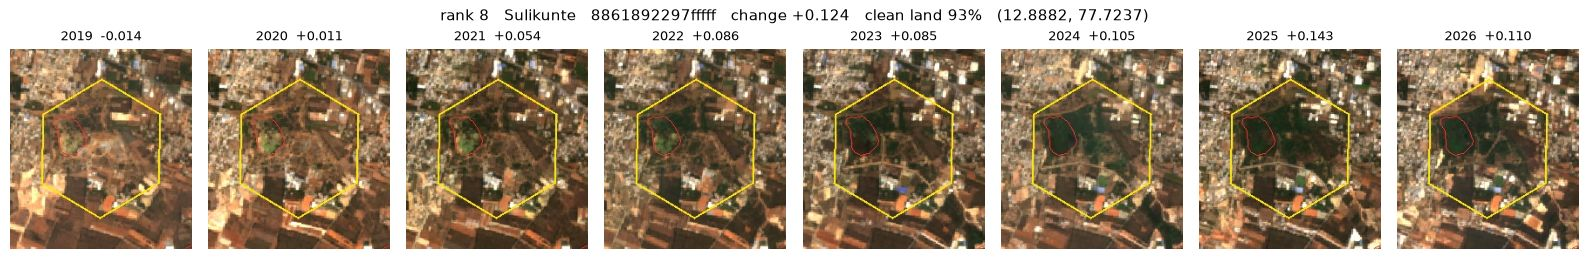

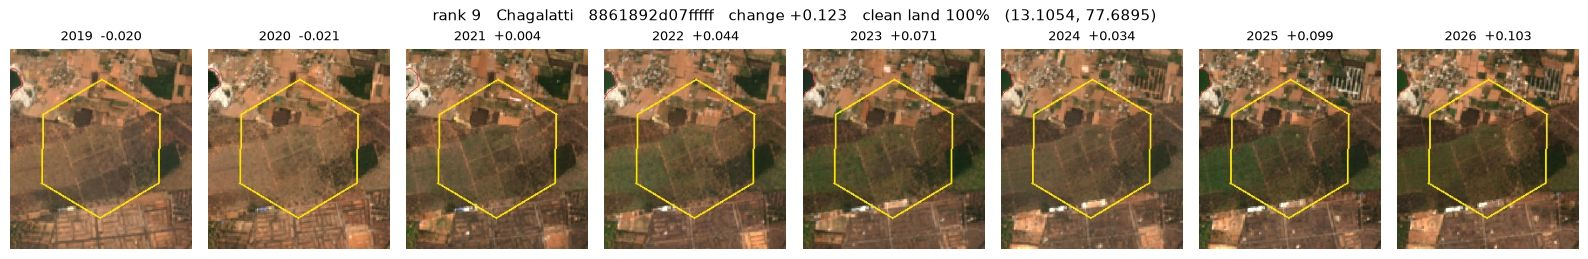

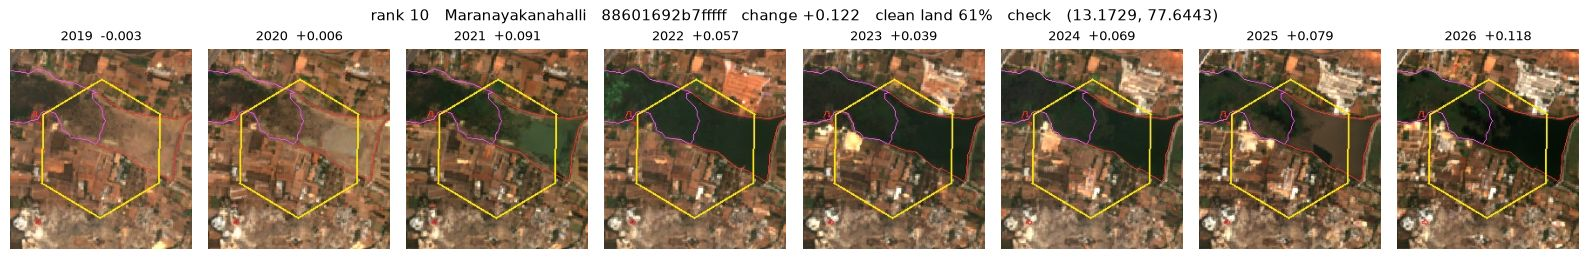

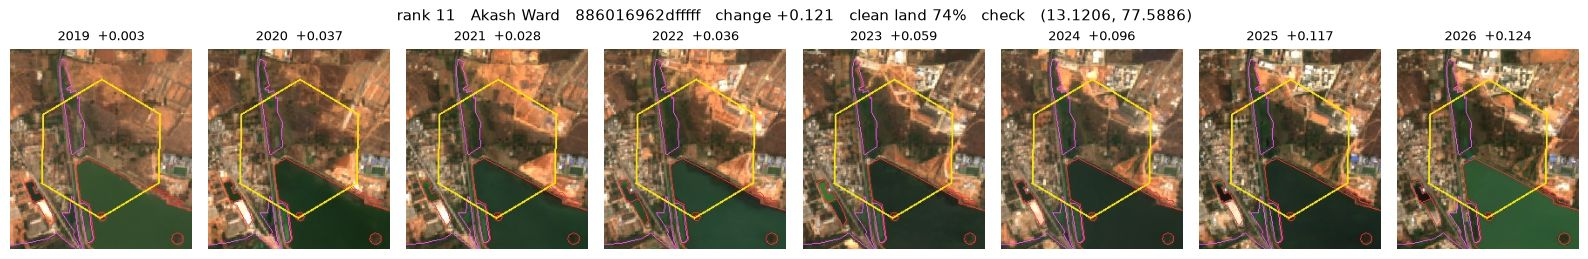

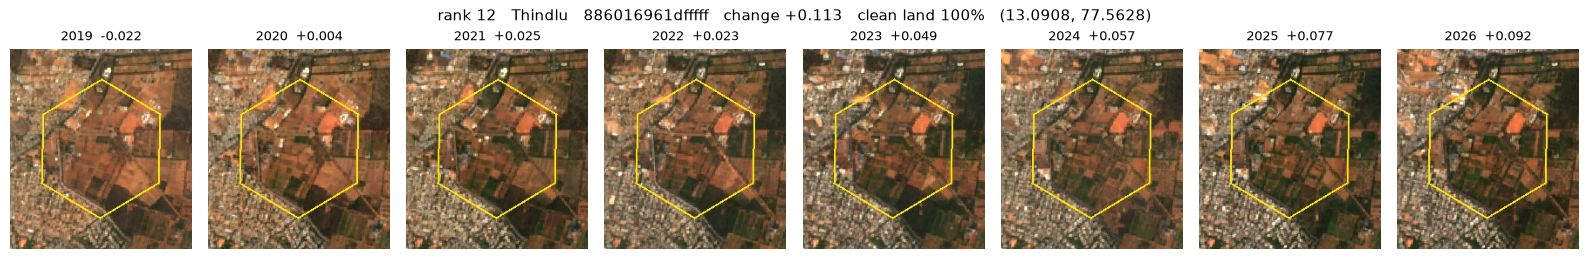

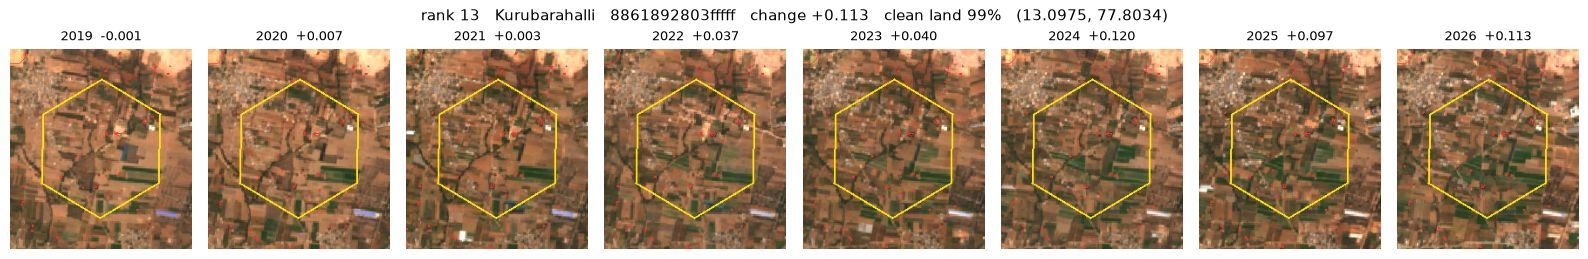

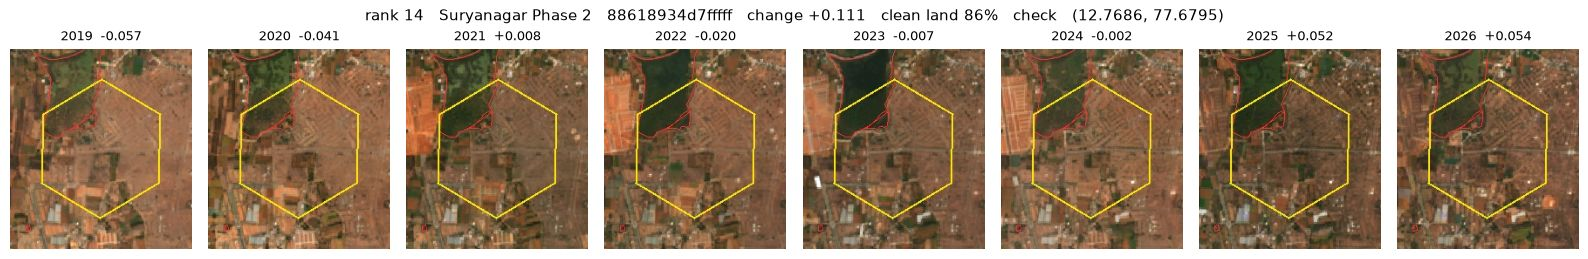

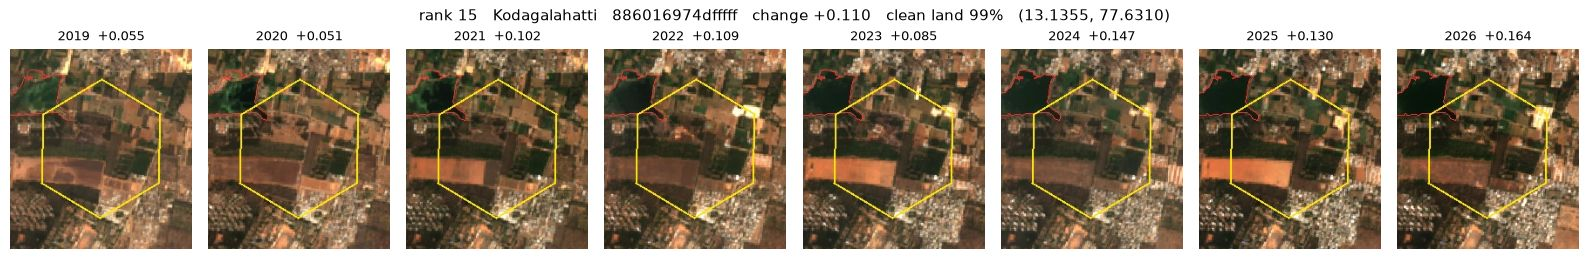

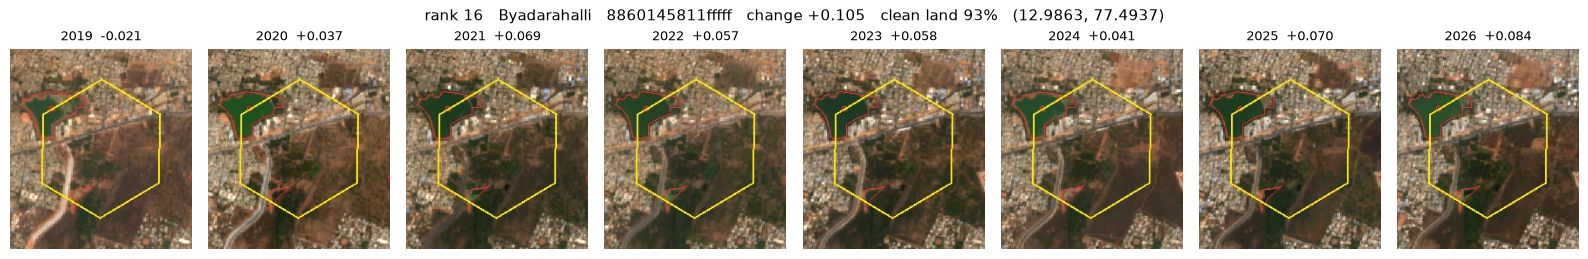

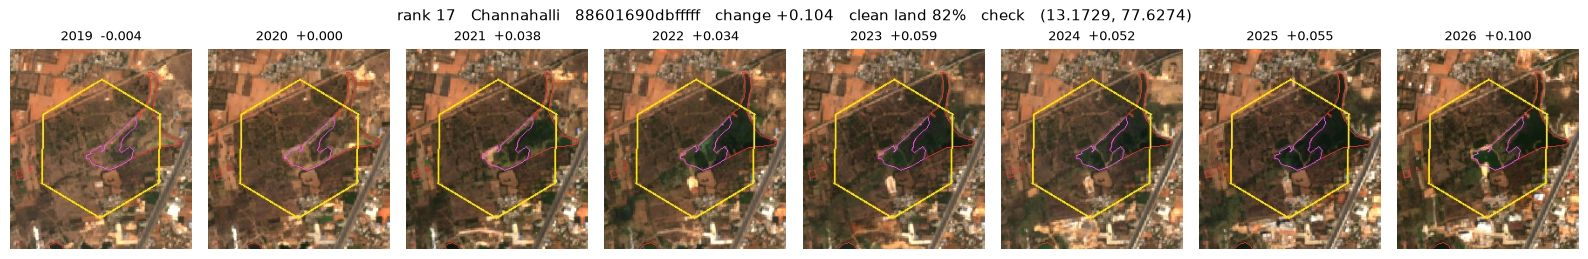

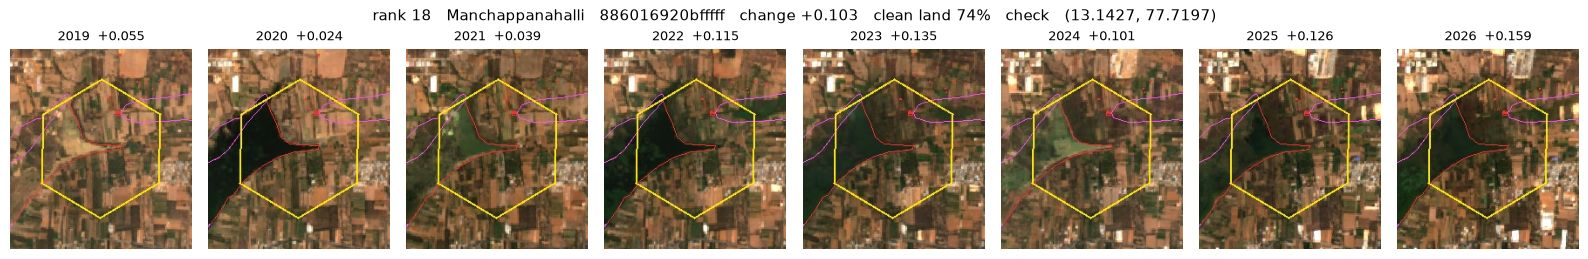

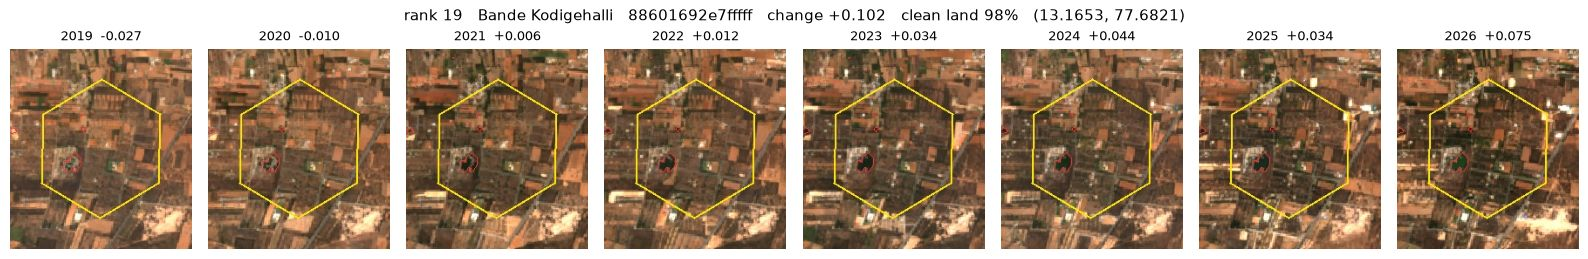

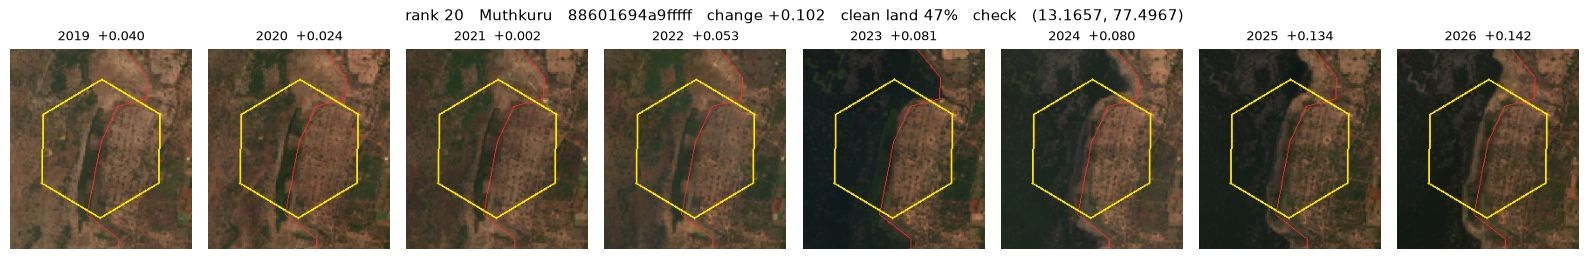

  retrying after HTTPError


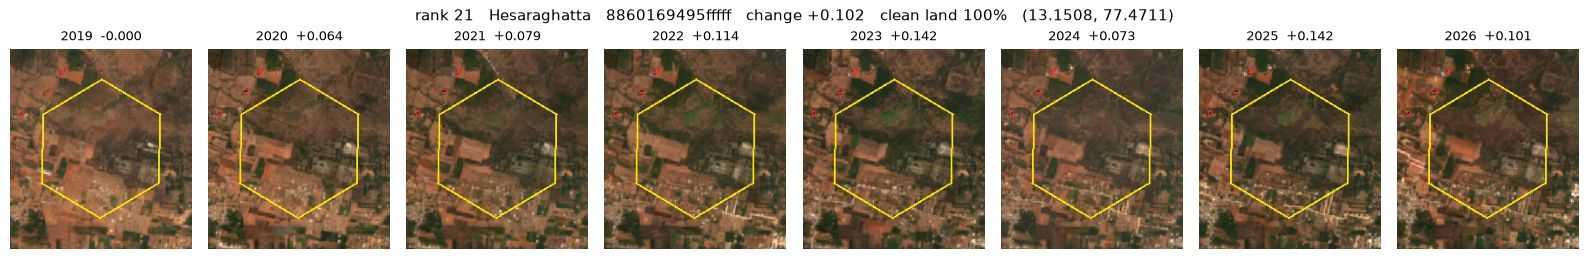

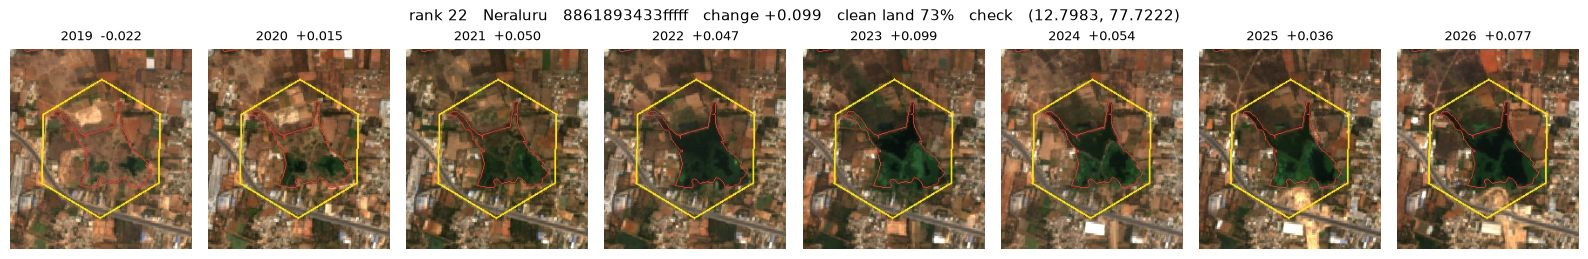

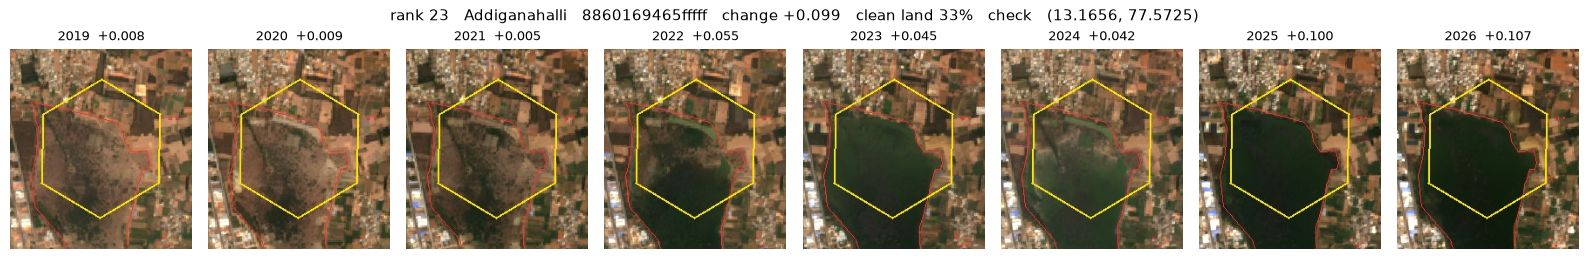

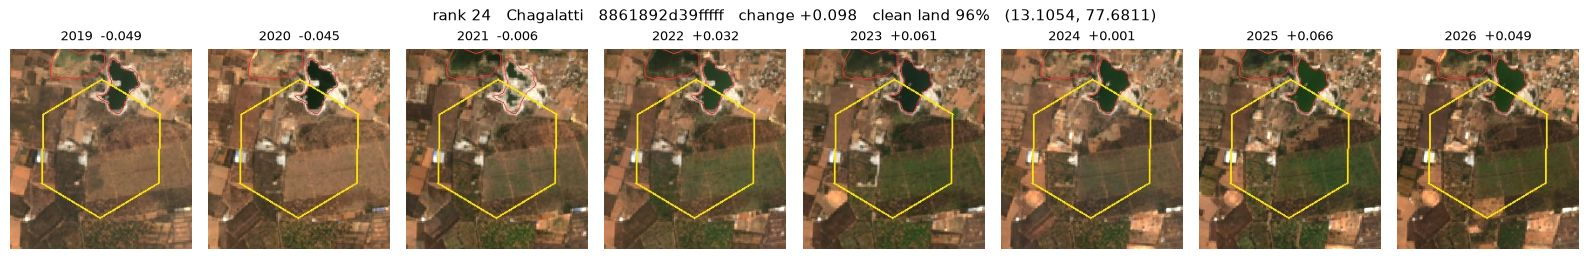

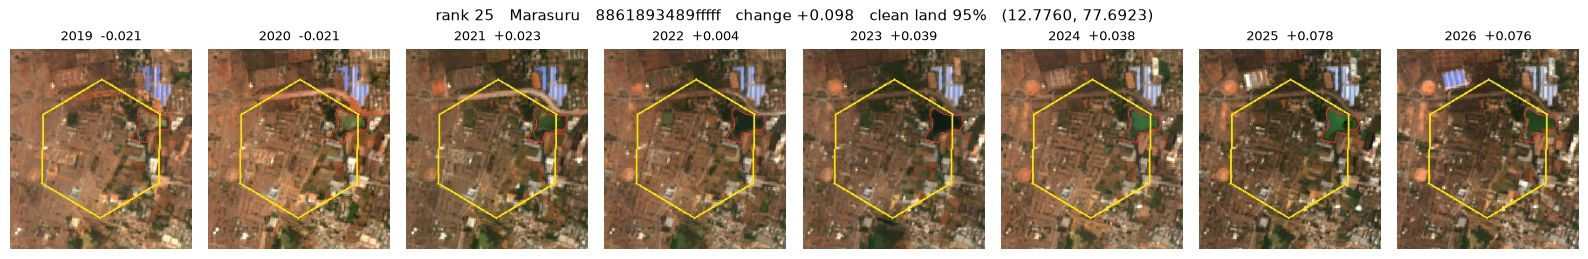

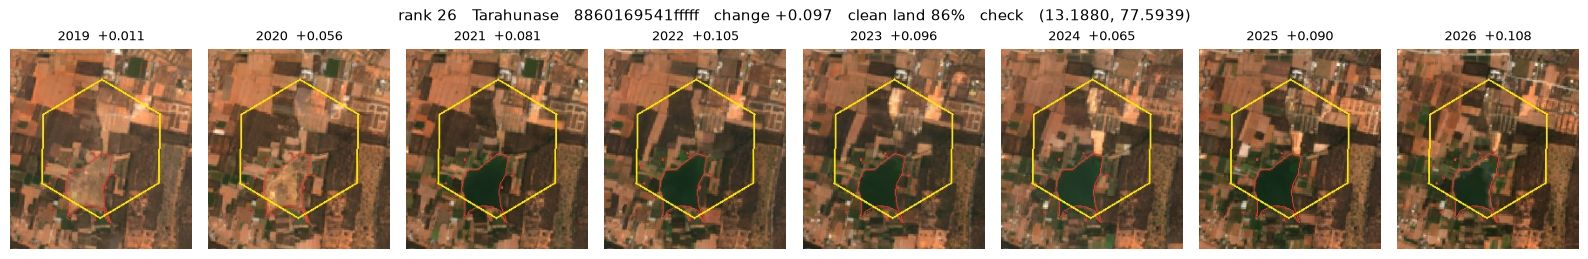

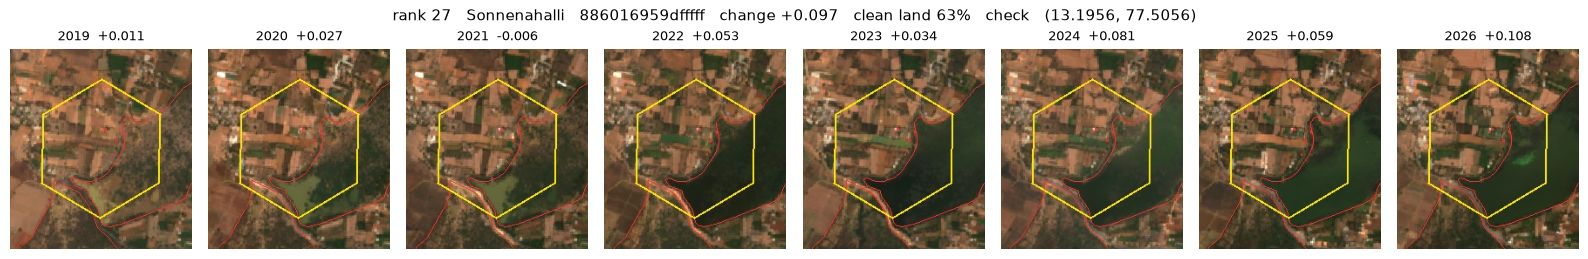

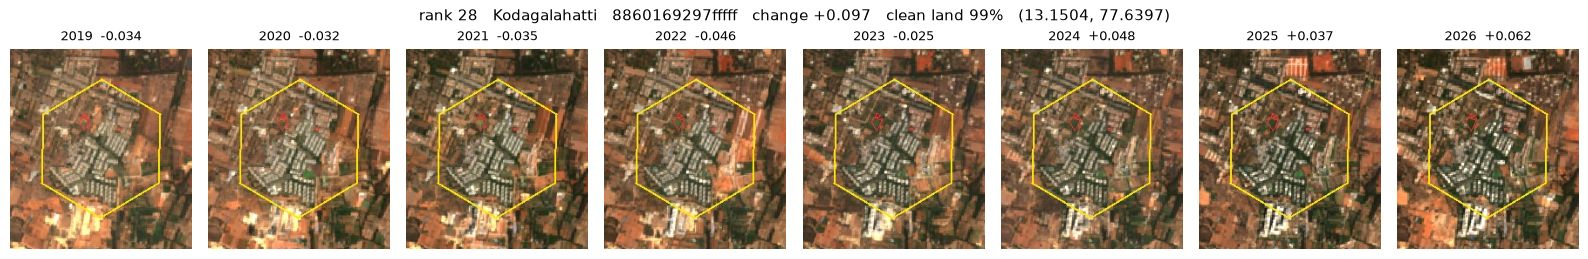

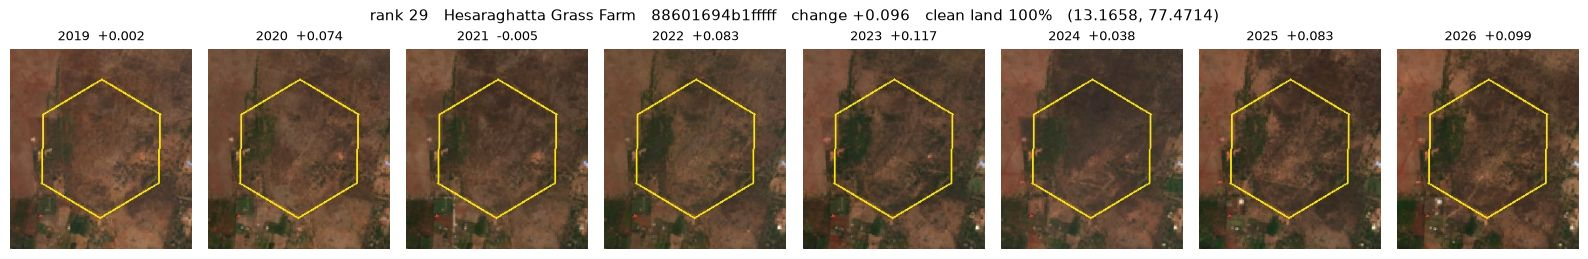

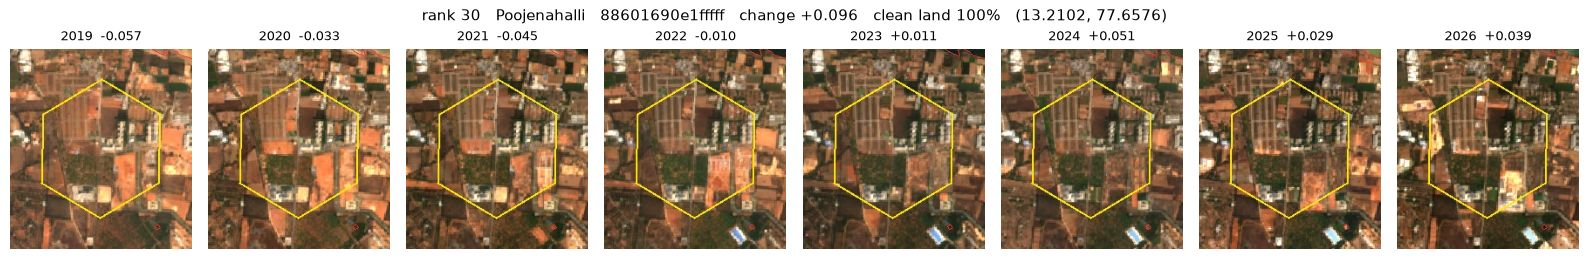

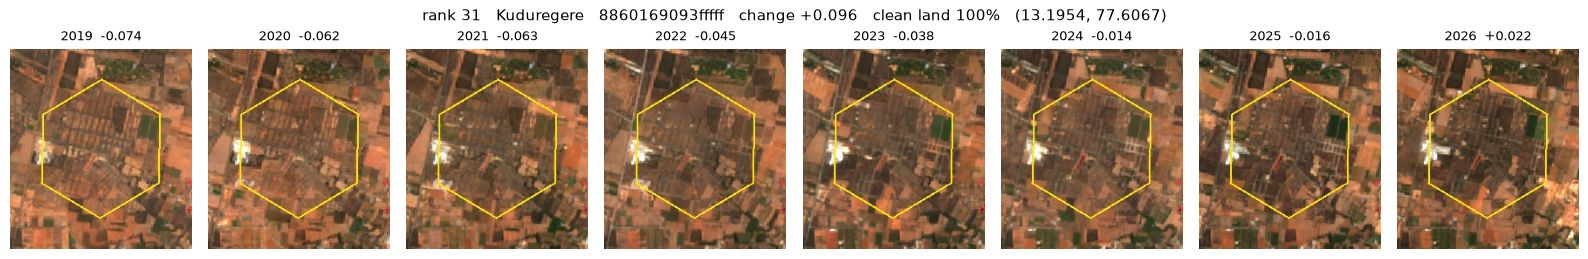

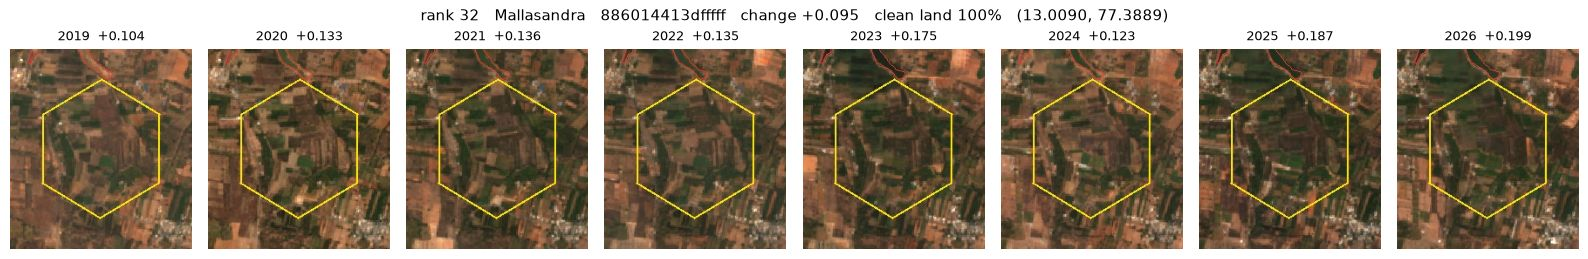

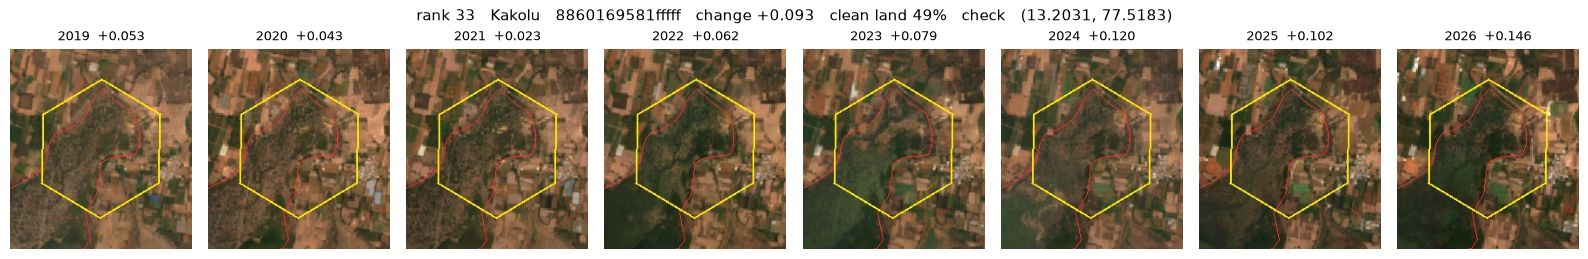

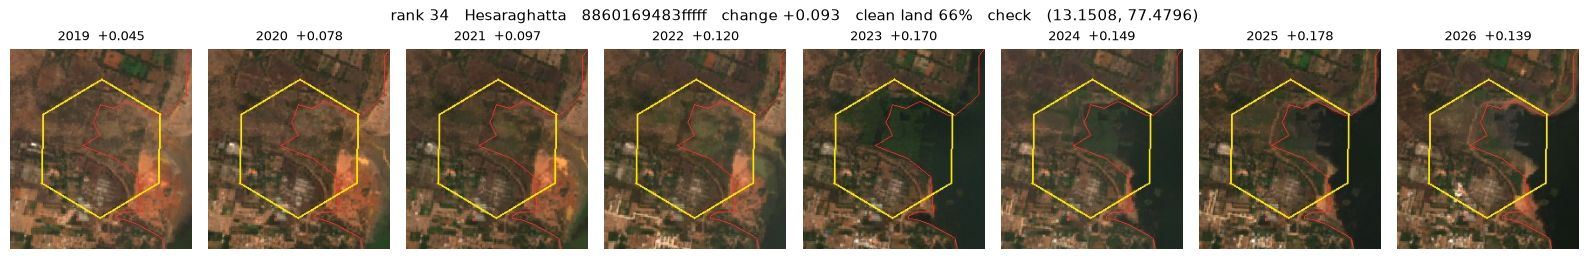

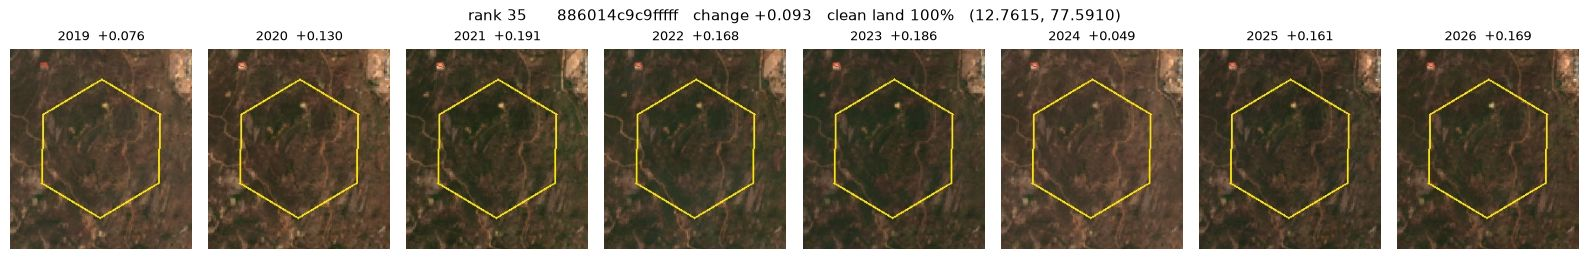

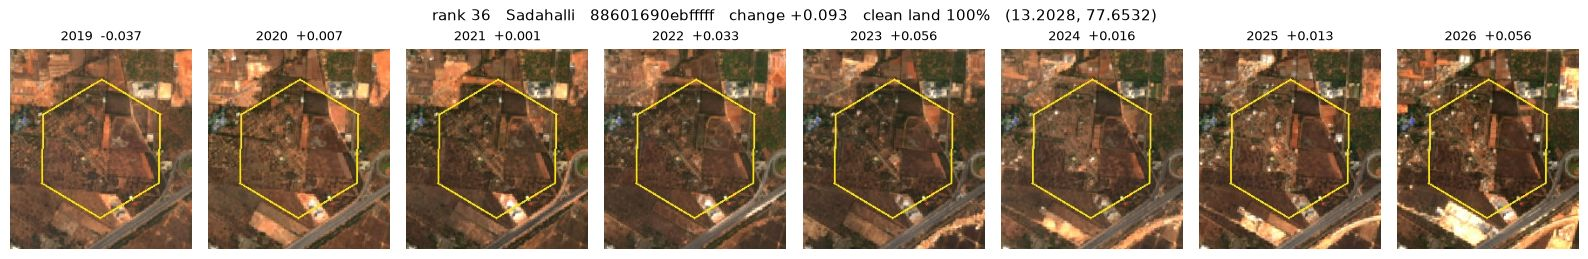

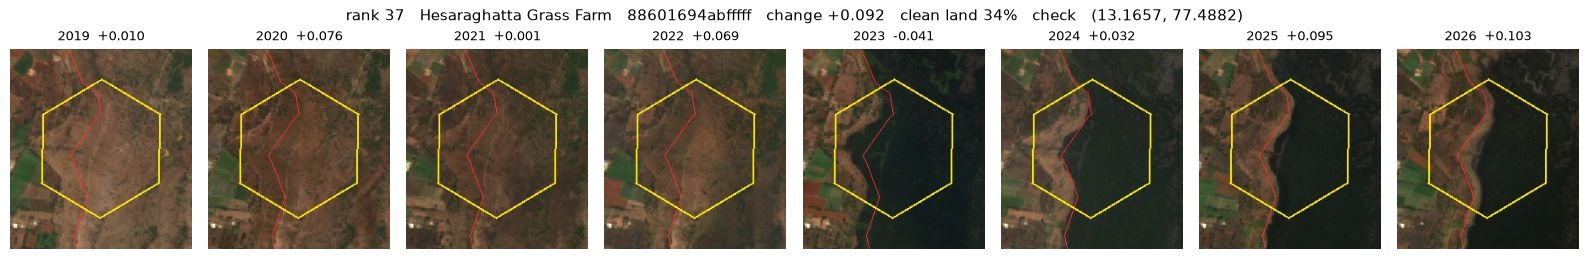

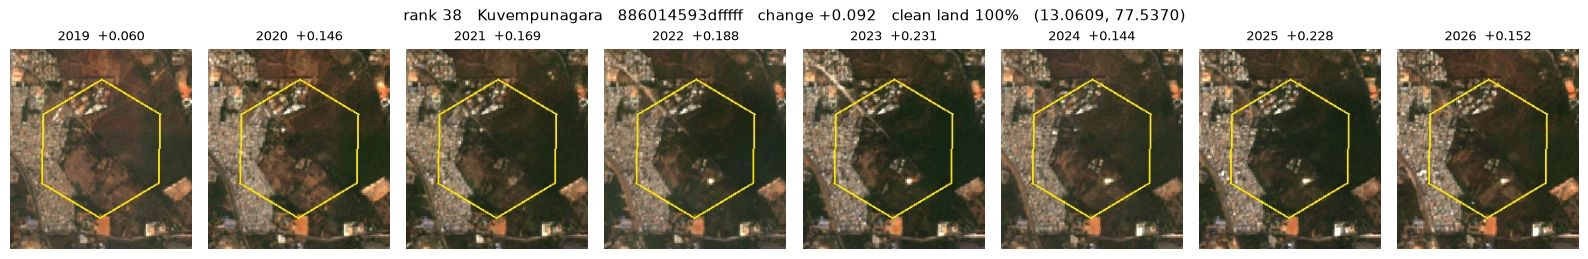

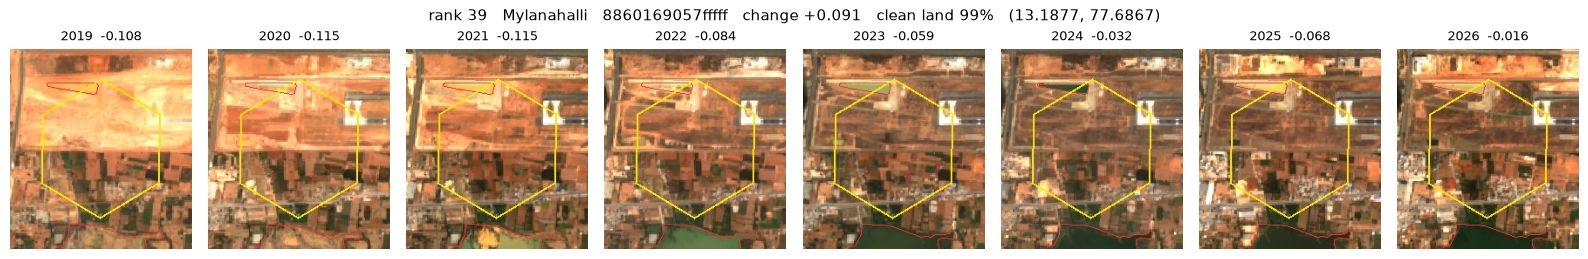

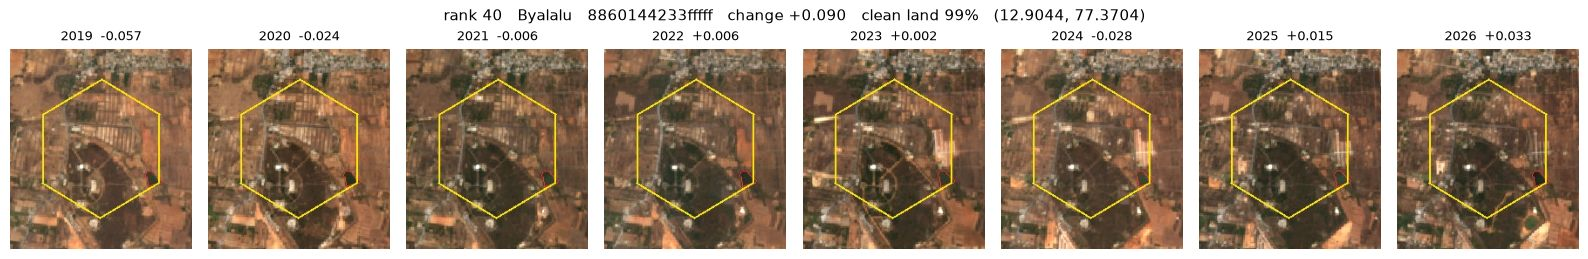

In [3]:
for hx in gains:
    geom = hex_geom(hx)
    lat, lng = h3.cell_to_latlng(hx)
    region = geom.buffer(250).bounds()
    bounds = (lng - 0.012, lat - 0.012, lng + 0.012, lat + 0.012)
    edges = [e for e in (outline(near(masked, bounds), MASK_EDGE),
                         outline(near(wetland, bounds), WETLAND_EDGE),
                         ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(geom)]), 1, 2)
                         .selfMask().visualize(palette=[HEX_EDGE])) if e is not None]
    fig, axes = plt.subplots(1, len(YEARS), figsize=(16, 2.6))
    for ax, year in zip(axes, YEARS):
        rgb = composite(year, region).visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX)
        for e in edges:
            rgb = rgb.blend(e)
        ax.imshow(thumb(rgb, region))
        ax.set_title(f"{year}  {norm.loc[hx, year]:+.3f}", fontsize=9)
        ax.set_axis_off()
    flag = "   check" if clean_land[hx] < CLEAN_CUTOFF else ""
    fig.suptitle(f"rank {rank[hx]}   {locality(hx)}   {hx}   change {change[hx]:+.3f}   "
                 f"clean land {clean_land[hx]:.0%}{flag}   ({lat:.4f}, {lng:.4f})", fontsize=10.5)
    plt.tight_layout(); plt.show()

---
## 3 — A verdict for every one of the 40

Written by eye from the photos in section 2, with a high-resolution look at each hex for the calls
the 10 m frames can't make (plantation rows, plotted layouts). Stored in
`results/m2_gain_verdicts.csv`, one row per hex with a one-line note of what the photos show. Below:
the counts, the verdicts against the `check` flag, the hexes that make more than half their rise in
the single step from 2019 to 2020, and which hexes leave the top 40 if the start year is 2020
instead (`rank_from_2020` in the CSV).

In [4]:
HEADLINE = ("real gain",)

verdicts = pd.read_csv("results/m2_gain_verdicts.csv").set_index("h3")
assert list(verdicts.index) == list(gains)
print(verdicts.verdict.value_counts().to_string())
print(f"\nheadline list (real gain, photo-evident): {verdicts.verdict.isin(HEADLINE).sum()} of {TOP}\n")
print(pd.crosstab(verdicts.verdict, (clean_land[gains] < CLEAN_CUTOFF).map({True: "check", False: "clean"}),
                  margins=True).to_string())

first_step = ((norm[YEARS[1]] - norm[YEARS[0]]) / change)[gains]
early = first_step[first_step > 0.5].index
print(f"\nmore than half of the rise in {YEARS[0]}->{YEARS[1]}: "
      + ", ".join(f"rank {rank[h]} ({verdicts.verdict[h]}, {first_step[h]:.0%})" for h in early))
from_2020 = verdicts.rank_from_2020
left = verdicts.index[from_2020 > TOP]
print(f"\nleave the top {TOP} with a {YEARS[1]} start: {len(left)} — "
      + ", ".join(f"rank {rank[h]} ({verdicts.verdict[h]}, now {from_2020[h]})" for h in left))
print(f"headline hexes still in the top {TOP} with a {YEARS[1]} start: "
      f"{(verdicts.verdict.isin(HEADLINE) & (from_2020 <= TOP)).sum()} of {verdicts.verdict.isin(HEADLINE).sum()}")
with pd.option_context("display.max_colwidth", 95, "display.width", 250):
    print()
    print(verdicts.set_index("rank")[["locality", "change", "verdict", "note"]].to_string())

verdict
lake margin    13
doubtful       13
real gain       6
crop swing      3
regrowth        3
artefact        2

headline list (real gain, photo-evident): 6 of 40

col_0        check  clean  All
verdict                       
artefact         2      0    2
crop swing       1      2    3
doubtful         2     11   13
lake margin     11      2   13
real gain        0      6    6
regrowth         1      2    3
All             17     23   40

more than half of the rise in 2019->2020: rank 16 (doubtful, 55%), rank 21 (doubtful, 64%), rank 29 (crop swing, 75%), rank 35 (doubtful, 58%), rank 37 (artefact, 71%), rank 38 (doubtful, 94%)

leave the top 40 with a 2020 start: 13 — rank 16 (doubtful, now 173), rank 21 (doubtful, now 297), rank 22 (lake margin, now 80), rank 26 (doubtful, now 131), rank 29 (crop swing, now 545), rank 30 (doubtful, now 53), rank 32 (doubtful, now 68), rank 34 (lake margin, now 84), rank 35 (doubtful, now 258), rank 36 (doubtful, now 164), rank 37 (artefact, now 

---
## What this shows

**6 of the 40 biggest gains are real, photo-evident tree gain, and all six are plantations or
planting, not restoration.** Every one of them is clean (no `check` flag) and all six stay in the top
40 with a 2020 start, so none leans on 2019.

| verdict | count | what they are |
|---|---|---|
| real gain | 6 | Jarakabandekaval's plantation blocks (ranks 3, 4); a tree plantation at Chagalatti (9, 24); plantation blocks at Kodagalahatti (15); a villa township's gardens growing in (28) |
| lake margin | 13 | tanks that refilled from 2021-23 (Doddajala, Bande Kodigehalli, Neraluru, Addiganahalli, Sonnenahalli, Hesaraghatta's shore) with weed, marsh or grass spreading over the bed, often past the mapped outline |
| doubtful | 13 | farms, orchards and plotted layouts rising slowly with nothing visible, and woodland whose rise is mostly a low 2019 (Kuvempunagara, Bannerghatta edge, Byadarahalli) |
| crop swing | 3 | Hesaraghatta north's farm plots (2), Kurubarahalli farmland (13), the Hesaraghatta Grass Farm (29) |
| regrowth | 3 | grass and scrub back on two empty plotted layouts (14, 31) and on the airport's 2019 earthworks (39) |
| artefact | 2 | Hennagara Lake, which OSM maps as a sliver (1), and a Hesaraghatta sliver that was underwater in 2023 (37) |

**The gain list is mostly water, not trees.** A third of it is a lake bed or shore greening as the
tank came back after the dry years, and both artefacts are lakes bigger than their map. That is the
same shoreline problem M4's 10-20 m band test is looking for, seen from the other side: after 2021
many northern tanks spread past outlines drawn at low water. The `check` flag catches 11 of the 13
lake margins and both artefacts, and none of the real gains.

**The 2019 start matters much more here than for the losses.** 13 of the 40 leave the top 40 with
a 2020 start (against 8 for the losses): 9 doubtful, 2 lake margins, the grass farm and the
Hesaraghatta sliver. 6 of the 40 make more than half their rise in 2019-2020 alone; Kuvempunagara's
woodland makes 94% of it there. Whatever held 2019 low, anything that simply recovered from it reads
as a gain, so a gain quoted from this list should hold with either start year.

**No restoration appears.** Kaikondrahalli, Jakkur and Rachenahalli are not in the top 40, which fits
M1's finding that a single modest restoration sits under the noise. **The best counter-example for M7
is Jarakabandekaval (ranks 3 and 4)**: two adjacent clean hexes of planted forest blocks closing into
canopy, the largest robust gains on the list, and a named forest area a reader can look up.
Chagalatti (9 and 24) is the backup: one plantation spanning two hexes, rows visible in 2019 and a
closed block by 2026.